In [1]:
from google.colab import files
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
uploaded = files.upload()  # upload student_feedback_classified.csv
df = pd.read_csv('student_feedback_classified (1).csv')
print(df.shape, df.dtypes)

Saving student_feedback_classified (1).csv to student_feedback_classified (1) (1).csv
(959, 8) Department                   object
Section                      object
Q1_Teaching effectiveness     int64
Q2_Content Quality            int64
Q3_Classroom interaction      int64
Q4_Resource                   int64
Q5_Overall Experience         int64
Class                        object
dtype: object


In [4]:
# Encode categorical columns
le_dept = LabelEncoder()
le_sec  = LabelEncoder()
le_cls  = LabelEncoder()

df['Dept_enc']    = le_dept.fit_transform(df['Department'])
df['Section_enc'] = le_sec.fit_transform(df['Section'])
df['Class_enc']   = le_cls.fit_transform(df['Class'])   # Negative=0, Neutral=1, Positive=2

# Feature matrix (use Q1–Q5 + encoded columns for clustering)
feature_cols = ['Q1_Teaching effectiveness','Q2_Content Quality',
                'Q3_Classroom interaction','Q4_Resource','Q5_Overall Experience',
                'Dept_enc','Section_enc']
X = df[feature_cols].copy()

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

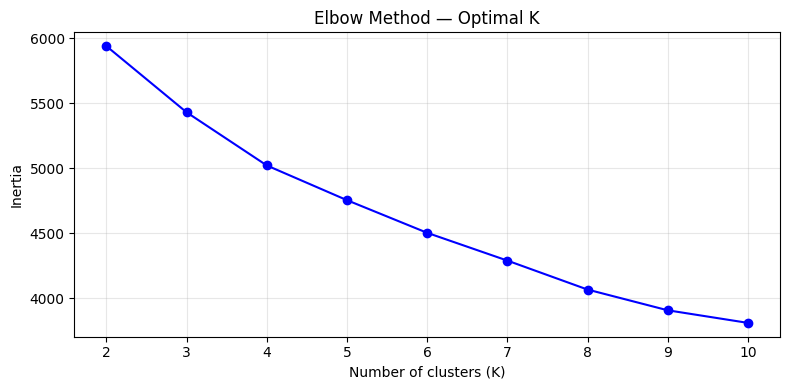

In [5]:
inertias = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8,4))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Optimal K')
plt.xticks(K_range)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

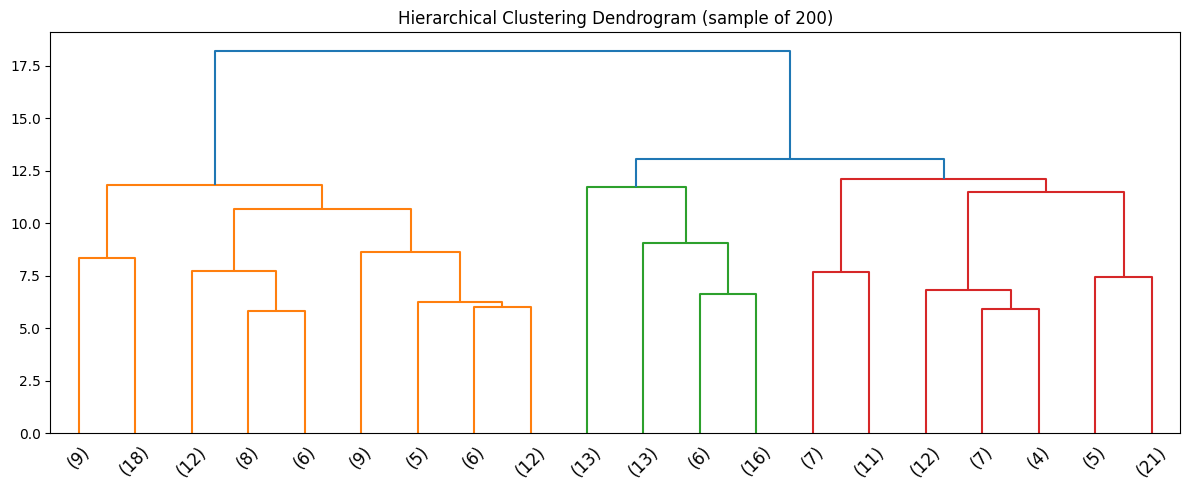

In [ ]:
# ── K-Means ──────────────────────────────────────────────────────────────────
km = KMeans(n_clusters=3, random_state=42, n_init=10)
df['KMeans_Cluster'] = km.fit_predict(X_scaled)

# ── Gaussian Mixture Model (EM) ───────────────────────────────────────────────
gmm = GaussianMixture(n_components=3, random_state=42, n_init=5)
df['GMM_Cluster'] = gmm.fit_predict(X_scaled)

# ── Hierarchical (Agglomerative) ──────────────────────────────────────────────
agg = AgglomerativeClustering(n_clusters=3, linkage='ward')
df['Agg_Cluster'] = agg.fit_predict(X_scaled)

# ── Dendrogram (for Hierarchical) ────────────────────────────────────────────
linked = linkage(X_scaled[:200], method='ward')   # sample for speed
plt.figure(figsize=(12, 5))
dendrogram(linked, truncate_mode='lastp', p=20, leaf_rotation=45)
plt.title('Hierarchical Clustering Dendrogram (sample of 200)')
plt.tight_layout()
plt.show()

In [ ]:
results = {}
for method, col in [('KMeans', 'KMeans_Cluster'),
                    ('GMM',    'GMM_Cluster'),
                    ('Hierarchical', 'Agg_Cluster')]:
    labels = df[col]
    sil = silhouette_score(X_scaled, labels)
    db  = davies_bouldin_score(X_scaled, labels)
    results[method] = {'Silhouette ↑': round(sil, 4),
                       'Davies-Bouldin ↓': round(db, 4)}

print(pd.DataFrame(results).T.to_string())

              Silhouette ↑  Davies-Bouldin ↓
KMeans              0.1076            2.4549
GMM                 0.0990            2.5379
Hierarchical        0.0710            2.8006


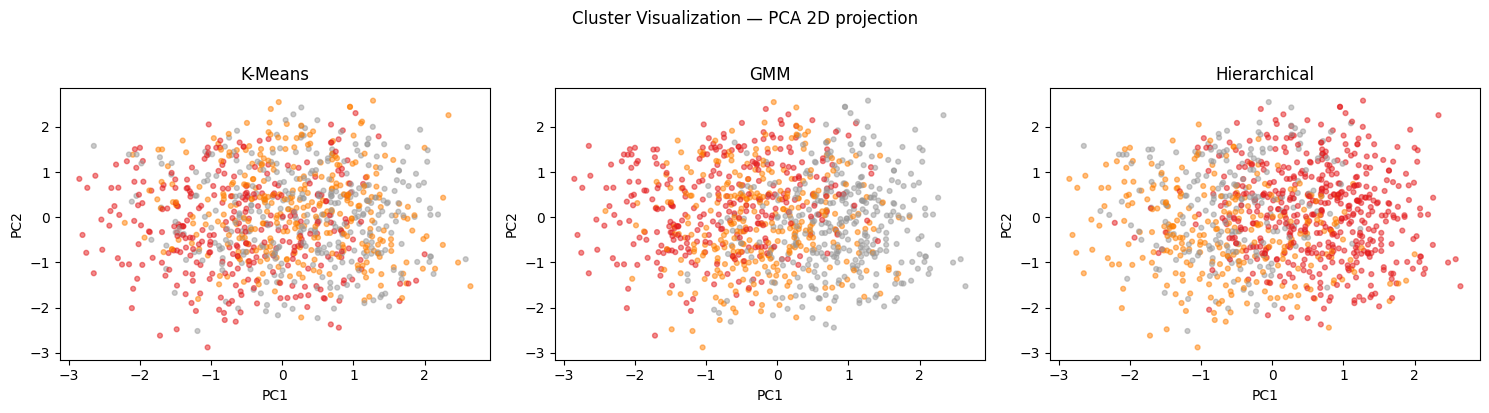

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (method, col) in zip(axes,
        [('K-Means','KMeans_Cluster'),
         ('GMM','GMM_Cluster'),
         ('Hierarchical','Agg_Cluster')]):
    sc = ax.scatter(X_pca[:,0], X_pca[:,1],
                    c=df[col], cmap='Set1', alpha=0.5, s=12)
    ax.set_title(method)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

plt.suptitle('Cluster Visualization — PCA 2D projection', y=1.02)
plt.tight_layout()
plt.show()

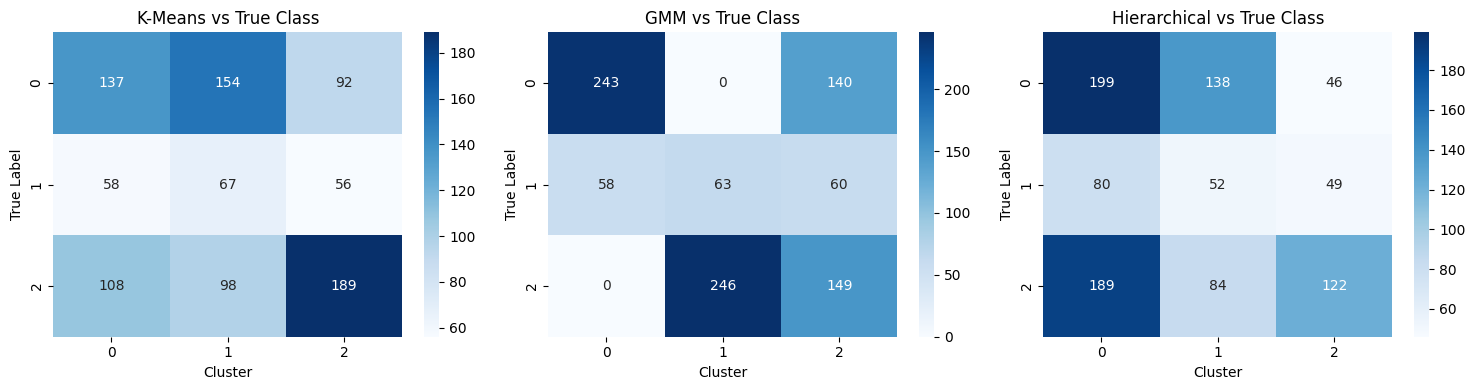

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (method, col) in zip(axes,
        [('K-Means','KMeans_Cluster'),
         ('GMM','GMM_Cluster'),
         ('Hierarchical','Agg_Cluster')]):
    cm = confusion_matrix(df['Class_enc'], df[col])
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues')
    ax.set_title(f'{method} vs True Class')
    ax.set_xlabel('Cluster')
    ax.set_ylabel('True Label')
plt.tight_layout()
plt.show()

# Save enriched dataset
df.to_csv('student_feedback_clustered.csv', index=False)
files.download('student_feedback_clustered.csv')

In [ ]:
# Convert CSV to ARFF for Weka
def csv_to_arff(df, relation_name, filename):
    lines = [f'@RELATION {relation_name}\n']
    for col in df.columns:
        if df[col].dtype == object:
            vals = ','.join(sorted(df[col].dropna().unique()))
            lines.append(f'@ATTRIBUTE {col} {{{vals}}}')
        else:
            lines.append(f'@ATTRIBUTE {col} NUMERIC')
    lines.append('\n@DATA')
    for _, row in df.iterrows():
        lines.append(','.join(str(v) for v in row.values))
    with open(filename, 'w') as f:
        f.write('\n'.join(lines))
    print(f'Saved: {filename}')

# Use original CSV (Weka handles categoricals natively)
csv_to_arff(df[['Department','Section',
                'Q1_Teaching effectiveness','Q2_Content Quality',
                'Q3_Classroom interaction','Q4_Resource',
                'Q5_Overall Experience','Class']],
            'student_feedback',
            'student_feedback.arff')
files.download('student_feedback.arff')

Saved: student_feedback.arff


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>